## READ ME
*   Note: ONLY run (1) and (3) for DI-attack implement.
*   Make file directories are defined appropriately

*DI-Attack Implemenation on SR model Mobile-ViT*
*Code developed by Lhamo Dorje and Dr. Xiaohua (Edward) Li, ECE Department, Binghamton University, November 2025*



### (1) Core MobileVIT Model

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# Following is the model used by the authors in “A Vision Transformer Approach
# for Efficient Near-Field Irregular SAR Super-Resolution.”

# ============================================================
# HFFH_ViT: Hybrid Freehand Imaging ViT (MobileViT-style)
# Approximation faithful to the printed architecture you gave
# Input:  (B, 3, H, W)
# Output: (B, 3, H, W)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------- Core transformer components ----------

class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn = fn

    def forward(self, x):
        # x: (B, N, dim)
        return self.fn(self.norm(x))


class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Attention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=8, dropout=0.0):
        """
        dim: token embedding dim (8 or 16 in HFFH_ViT)
        heads: 4, so 3 * heads * dim_head = 96 = to_qkv out_features
        dim_head: 8
        """
        super().__init__()
        inner_dim = dim_head * heads * 3  # for q, k, v
        self.heads = heads
        self.dim_head = dim_head

        self.to_qkv = nn.Linear(dim, inner_dim, bias=False)
        self.attend = nn.Softmax(dim=-1)
        self.to_out = nn.Sequential(
            nn.Linear(dim_head * heads, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        """
        x: (B, N, dim)
        """
        b, n, _ = x.shape
        qkv = self.to_qkv(x)  # (B, N, 3 * heads * dim_head)
        qkv = qkv.view(b, n, 3, self.heads, self.dim_head)
        q, k, v = qkv.unbind(dim=2)  # each: (B, N, heads, dim_head)

        # (B, heads, N, dim_head)
        q = q.permute(0, 2, 1, 3)
        k = k.permute(0, 2, 1, 3)
        v = v.permute(0, 2, 1, 3)

        scale = self.dim_head ** -0.5
        dots = torch.matmul(q, k.transpose(-1, -2)) * scale  # (B, heads, N, N)
        attn = self.attend(dots)
        out = torch.matmul(attn, v)                           # (B, heads, N, dim_head)

        # (B, N, heads * dim_head)
        out = out.permute(0, 2, 1, 3).contiguous().view(b, n, self.heads * self.dim_head)
        out = self.to_out(out)  # (B, N, dim)
        return out


class Transformer(nn.Module):
    def __init__(self, dim, depth, mlp_dim, heads=4, dim_head=8, dropout=0.0):
        """
        dim: token dimension (8 or 16)
        depth: number of transformer layers
        mlp_dim: hidden dim in FFN (paper uses ~2x or 4x)
        """
        super().__init__()
        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                PreNorm(dim, Attention(dim, heads=heads, dim_head=dim_head, dropout=dropout)),
                PreNorm(dim, FeedForward(dim, mlp_dim, dropout=dropout)),
            ]))

    def forward(self, x):
        for attn, ff in self.layers:
            x = x + attn(x)
            x = x + ff(x)
        return x

# ---------- MobileViT-style blocks ----------

class MV2Block(nn.Module):
    """
    MobileNetV2-style depthwise separable block.
    Matches the printed pattern:
      Conv2d(C,C,3x3,groups=C) -> BN -> SiLU -> Conv2d(C,C or C->C') -> BN
    With residual if in==out and stride==1.
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=stride,
                      padding=1, groups=in_channels, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.SiLU(inplace=False),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )
        self.use_res_connect = (stride == 1 and in_channels == out_channels)

    def forward(self, x):
        out = self.conv(x)
        if self.use_res_connect:
            out = out + x
        return out


class MobileViTBlock(nn.Module):
    """
    MobileViT-style block:
      conv1: 3x3 (C->C)
      conv2: 1x1 (C->transformer_dim)
      transformer over patches in token dim = transformer_dim
      conv3: 1x1 (transformer_dim->C)
      conv4: 3x3 on concat(local, global) (2C->C)

    patch_size controls how big each transformer patch is (e.g., (2,2) or (4,4)).
    """
    def __init__(self, in_channels, transformer_dim, depth,
                 patch_size=(2, 2), mlp_dim=None, heads=4, dim_head=8, dropout=0.0):
        super().__init__()
        ph, pw = patch_size
        self.patch_h = ph
        self.patch_w = pw
        self.transformer_dim = transformer_dim

        # Local conv
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1,
                      padding=1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.SiLU(inplace=False),
        )

        # Channel projection: C -> transformer_dim (8 or 16)
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels, transformer_dim, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(transformer_dim),
            nn.SiLU(inplace=False),
        )

        if mlp_dim is None:
            mlp_dim = transformer_dim * 2  # you can change to *4 if you want to mimic 4x layers

        self.transformer = Transformer(
            dim=transformer_dim,
            depth=depth,
            mlp_dim=mlp_dim,
            heads=heads,
            dim_head=dim_head,
            dropout=dropout,
        )

        # Back to conv space: transformer_dim -> in_channels
        self.conv3 = nn.Sequential(
            nn.Conv2d(transformer_dim, in_channels, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.SiLU(inplace=False),
        )

        # Fuse local+global: (2C -> C)
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels * 2, in_channels, kernel_size=3, stride=1,
                      padding=1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.SiLU(inplace=False),
        )

    def forward(self, x):
        # x: (B, C, H, W)
        local_x = self.conv1(x)
        y = self.conv2(local_x)   # (B, transformer_dim, H, W)
        B, C, H, W = y.shape
        assert C == self.transformer_dim

        ph, pw = self.patch_h, self.patch_w

        # Pad so H,W divisible by patch size
        pad_h = (ph - H % ph) % ph
        pad_w = (pw - W % pw) % pw
        if pad_h != 0 or pad_w != 0:
            y = F.pad(y, (0, pad_w, 0, pad_h), mode="reflect")
            B, C, H, W = y.shape

        self._orig_hw = (H, W)

        # Unfold into non-overlapping patches
        # y_unfold: (B, C*ph*pw, L)
        y_unfold = F.unfold(y, kernel_size=(ph, pw), stride=(ph, pw))
        # reshape to (B, C, ph*pw, L) then average over patch pixels -> (B, C, L)
        y_unfold = y_unfold.view(B, C, ph * pw, -1).mean(dim=2)
        # tokens: (B, L, C)
        tokens = y_unfold.permute(0, 2, 1).contiguous()

        # Transformer over tokens
        tokens = self.transformer(tokens)  # (B, L, C)

        # Map tokens back to patches, broadcast to ph*pw pixels, fold back
        t = tokens.permute(0, 2, 1)                 # (B, C, L)
        t = t.unsqueeze(2).repeat(1, 1, ph * pw, 1) # (B, C, ph*pw, L)
        t = t.view(B, C * ph * pw, -1)              # (B, C*ph*pw, L)
        y = F.fold(t, output_size=(H, W), kernel_size=(ph, pw), stride=(ph, pw))

        # Crop to original (if we padded)
        orig_H, orig_W = self._orig_hw
        y = y[:, :, :orig_H, :orig_W]

        # Project back and fuse with local conv features
        y = self.conv3(y)
        out = torch.cat((x, y), dim=1)
        out = self.conv4(out)
        return out


# ---------- HFFH_ViT full network ----------

class HFFH_ViT(nn.Module):
    """
    Hybrid Freehand Imaging ViT
    - Input:  (B, 3, H, W)
    - Output: (B, 3, H, W)
    Matches the high-level structure you pasted:
      conv1: 1->16
      stem:  4x MV2Block(16->16)
      trunk:
        Stage1: MV2(16->16) + MobileViTBlock(16,8,depth=2)
        Stage2: MV2(16->16) + MobileViTBlock(16,8,depth=4)
        Stage3: MV2(16->32) + MobileViTBlock(32,16,depth=3)
      head:  1x1 conv 32->1
    """
    def __init__(self, img_channels=3, patch_size=(2, 2), dropout=0.0):
        super().__init__()

        # # Initial conv: img_channels -> 16
        self.conv1 = nn.Sequential(
            nn.Conv2d(img_channels, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.SiLU(inplace=False),
        )

        # Stem: 4× MV2Block(16->16)
        self.stem = nn.ModuleList([
            MV2Block(16, 16, stride=1),
            MV2Block(16, 16, stride=1),
            MV2Block(16, 16, stride=1),
            MV2Block(16, 16, stride=1),
        ])

        # Trunk: 3 stages
        self.trunk = nn.ModuleList()

        # Stage 1: channels 16, transformer_dim=8, depth=2 (as in printout)
        stage1 = nn.ModuleList([
            MV2Block(16, 16, stride=1),
            MobileViTBlock(
                in_channels=16,
                transformer_dim=8,
                depth=2,
                patch_size=patch_size,
                mlp_dim=16,      # 2x expansion for dim=8
                heads=4,
                dim_head=8,
                dropout=dropout,
            )
        ])
        self.trunk.append(stage1)

        # Stage 2: channels 16, transformer_dim=8, depth=4
        stage2 = nn.ModuleList([
            MV2Block(16, 16, stride=1),
            MobileViTBlock(
                in_channels=16,
                transformer_dim=8,
                depth=4,
                patch_size=patch_size,
                mlp_dim=32,      # 4x expansion for dim=8
                heads=4,
                dim_head=8,
                dropout=dropout,
            )
        ])
        self.trunk.append(stage2)

        # Stage 3: MV2 16->32, transformer_dim=16, depth=3
        stage3 = nn.ModuleList([
            MV2Block(16, 32, stride=1),
            MobileViTBlock(
                in_channels=32,
                transformer_dim=16,
                depth=3,
                patch_size=patch_size,
                mlp_dim=64,      # 4x expansion for dim=16
                heads=4,
                dim_head=8,
                dropout=dropout,
            )
        ])
        self.trunk.append(stage3)

        # Head: 32 -> 3
        '''
        self.condense_channels = nn.Sequential(
            nn.Sequential(
                nn.Conv2d(32, 1, kernel_size=1, stride=1, bias=False),
                nn.BatchNorm2d(1),
                nn.SiLU(inplace=False),
            )
        )
        '''
        # Head: 32 -> 3
        self.condense_channels = nn.Sequential(
            nn.Sequential(
                nn.Conv2d(32, 3, kernel_size=1, stride=1, bias=False),
                nn.BatchNorm2d(3),
                nn.SiLU(inplace=False),
            )
        )


    def forward(self, x):
        # x: (B,img_channels,H,W)
        x = self.conv1(x)  # (B,16,H,W)

        for block in self.stem:
            x = block(x)    # (B,16,H,W)

        # Trunk stages
        for stage in self.trunk:
            mv2, mvblock = stage
            x = mv2(x)
            x = mvblock(x)

        # Now 32 channels -> 1
        out = self.condense_channels(x)
        return out


# ---------- Sanity check in Colab ----------
'''
if __name__ == "__main__":
    model = HFFH_ViT(img_channels=1, patch_size=(2, 2), dropout=0.0)
    x = torch.randn(1, 1, 256, 256)  # dummy SAR magnitude
    y = model(x)
    print("Input shape :", x.shape)
    print("Output shape:", y.shape)
    print("Num params  :", sum(p.numel() for p in model.parameters()))
'''

'\nif __name__ == "__main__":\n    model = HFFH_ViT(img_channels=1, patch_size=(2, 2), dropout=0.0)\n    x = torch.randn(1, 1, 256, 256)  # dummy SAR magnitude\n    y = model(x)\n    print("Input shape :", x.shape)\n    print("Output shape:", y.shape)\n    print("Num params  :", sum(p.numel() for p in model.parameters()))\n'

### (2) Example: Real SAR Measurement SR Imaging using trained MobileVIT (MFA)

rawSAR (torch complex) → range FFT → MFA (torch, autograd) → \hat{x}_0 → Mobile-ViT → image \hat{x}

*<font color="orange"> NOTE: please run (1) to define the mobileVIT mode, before running the attack </font> *

#### 3.1 Test the trained model on the real sar measurement.

trueImage_complex (MATLAB complex) → |x| → normalize [0,1] → jet colormap → RGB PIL image → resize 256×256 → PyTorch tensor → Mobile-ViT → super-resolved image


In [ ]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Recreate the model exactly as in training
model = HFFH_ViT(img_channels=3, patch_size=(8, 8), dropout=0.0).to(device)

ckpt_path = "/content/drive/MyDrive/Colab Notebooks/Mobile_VIT_UTdallas/models/hffh_vit_best_epoch_050.pth"
state_dict = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print("Loaded Mobile-ViT from:", ckpt_path)

Loaded Mobile-ViT from: /content/drive/MyDrive/Colab Notebooks/Mobile_VIT_UTdallas/models/hffh_vit_best_epoch_050.pth


In [ ]:
import scipy.io as sio
import numpy as np

mat_path = "/content/drive/MyDrive/Colab Notebooks/Mobile_VIT_UTdallas/trueImage_complex.mat"   # change if different
mat = sio.loadmat(mat_path)

# This should be your 401x401 complex image
empm_complex = mat['trueImage_complex']       # shape (401, 401), complex
print(empm_complex.shape, empm_complex.dtype)

(401, 401) complex128


In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as T
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# empm_complex: (401,401) complex
mag = np.abs(empm_complex).astype(np.float32)
mag /= (mag.max() + 1e-12)          # [0,1]

# --- APPLY JET COLORMAP LIKE YOUR SYNTHETIC LR IMAGES ---
cmap = plt.get_cmap('jet')
jet_rgb = cmap(mag)[..., :3]        # (H,W,3), float in [0,1]
jet_uint8 = (jet_rgb * 255).astype(np.uint8)

pil_rgb = Image.fromarray(jet_uint8)   # this now looks like your LR PNG

vit_transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),                      # -> (3,256,256) in [0,1]
])

lr_tensor = vit_transform(pil_rgb).unsqueeze(0).to(device)  # (1,3,256,256)

In [ ]:
model.eval()
with torch.no_grad():
    sr_tensor = model(lr_tensor)

sr_img = sr_tensor[0].cpu().permute(1, 2, 0).numpy()
sr_img = np.clip(sr_img, 0.0, 1.0)

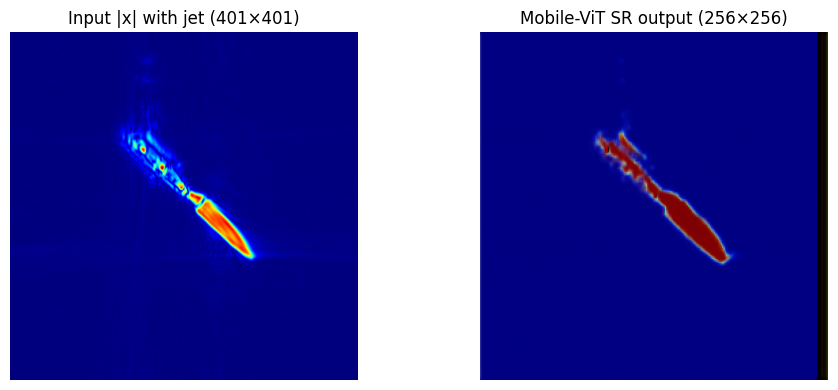

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(jet_rgb); plt.title("Input |x| with jet (401×401)"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(sr_img);  plt.title("Mobile-ViT SR output (256×256)"); plt.axis('off')
plt.tight_layout(); plt.show()

#### 3.2 Define Match Filter Algortihm
rawSAR (torch complex) → range FFT → MFA (torch, autograd) → jet RGB → Mobile-ViT → image

In [ ]:
import torch
from dataclasses import dataclass

@dataclass
class MFAParams:
    F0: float          # start freq (Hz), e.g. 77e9
    c0: float          # lightspeed, e.g. 3e8
    dx: float          # mm
    dy: float          # mm
    z0_mm: float       # target range (mm)
    bbox: tuple        # (xmin, xmax, ymin, ymax) in mm
    FS: float          # sampling rate (Hz)
    K0: float          # chirp slope (Hz/s)
    tI: float          # instrument delay (s)
    nFFTtime: int      # range FFT size, e.g. 1024
    nFFTspace: int     # spatial FFT size, e.g. 1024

def build_matched_filter(params: MFAParams, device, dtype):
    """
    PyTorch version of refMF(params) in MATLAB.
    Returns: matchedFilter (nFFTspace x nFFTspace), complex tensor.
    """
    nF = params.nFFTspace
    dx_m = params.dx * 1e-3
    dy_m = params.dy * 1e-3
    z0_m = params.z0_mm * 1e-3

    # Index grid like MATLAB: (-(nF-1)/2 : (nF-1)/2) * dx
    # Equivalent: indices = i - (nF/2 - 0.5)
    idx = torch.arange(nF, device=device, dtype=dtype) - (nF / 2 - 0.5)
    x = dx_m * idx                          # (nF,)
    y = dy_m * idx.view(-1, 1)              # (nF,1) -> broadcast

    k = 2.0 * torch.pi * params.F0 / params.c0   # wavenumber
    R = torch.sqrt(x**2 + y**2 + z0_m**2)        # (nF, nF)

    phase = -1j * 2.0 * k * R                    # -j 2 k R
    matched_filter = torch.exp(phase)            # complex64/complex128
    return matched_filter

def mfa_image_from_slice(sarData: torch.Tensor, params: MFAParams):
    """
    Differentiable PyTorch version of dlMFA.
    sarData: (M, N) complex tensor (after range FFT + serpentine)
    Returns:
        img_mag_norm: (B, A) real tensor, RMS-normalized magnitude
        img_complex : (B, A) complex tensor
    """
    assert torch.is_complex(sarData), "sarData must be complex (torch.complex64/128)"
    device = sarData.device
    dtype  = sarData.real.dtype

    # Build matched filter on same device/dtype
    mf = build_matched_filter(params, device=device, dtype=dtype)  # (nF, nF)

    yPointM, xPointM = sarData.shape
    yPointF, xPointF = mf.shape   # both nFFTspace

    # --- zero-pad sarData up to matched filter size (like MATLAB) ---
    pad_y_pre = max((yPointF - yPointM) // 2, 0)
    pad_y_post = max(yPointF - yPointM - pad_y_pre, 0)
    pad_x_pre = max((xPointF - xPointM) // 2, 0)
    pad_x_post = max(xPointF - xPointM - pad_x_pre, 0)

    if pad_y_pre > 0 or pad_y_post > 0:
        pad_y_top = torch.zeros(pad_y_pre, xPointM, dtype=sarData.dtype, device=device)
        pad_y_bot = torch.zeros(pad_y_post, xPointM, dtype=sarData.dtype, device=device)
        sarData = torch.cat([pad_y_top, sarData, pad_y_bot], dim=0)

    if pad_x_pre > 0 or pad_x_post > 0:
        y_curr = sarData.shape[0]
        pad_x_left  = torch.zeros(y_curr, pad_x_pre, dtype=sarData.dtype, device=device)
        pad_x_right = torch.zeros(y_curr, pad_x_post, dtype=sarData.dtype, device=device)
        sarData = torch.cat([pad_x_left, sarData, pad_x_right], dim=1)

    # 2D FFT of data and matched filter
    sar_fft = torch.fft.fft2(sarData)
    mf_fft  = torch.fft.fft2(mf)

    # Convolution in freq domain, then ifft2
    img_shifted = torch.fft.ifft2(sar_fft * mf_fft)

    # fftshift (2D)
    def fftshift2d(x):
        h, w = x.shape[-2:]
        return torch.roll(torch.roll(x, shifts=h//2, dims=-2),
                          shifts=w//2, dims=-1)

    img = fftshift2d(img_shifted)

    # Crop using bbox like MATLAB
    J, I = img.shape
    bbox = params.bbox
    dx = params.dx
    dy = params.dy

    # x indices
    xij0 = round(bbox[0] / dx - 0.5 + I / 2.0)
    xij1 = round(bbox[1] / dx - 0.5 + I / 2.0)
    # y indices
    ykl0 = round(bbox[2] / dy - 0.5 + J / 2.0)
    ykl1 = round(bbox[3] / dy - 0.5 + J / 2.0)

    # convert to Python ints / clamp
    x0 = max(int(xij0), 0)
    x1 = min(int(xij1), I-1)
    y0 = max(int(ykl0), 0)
    y1 = min(int(ykl1), J-1)

    img_cropped = img[y0:y1+1, x0:x1+1]         # (B, A) complex

    # fliplr
    img_complex = torch.flip(img_cropped, dims=[1])

    # RMS-normalized magnitude (like trueImage_abs)
    mag = torch.abs(img_complex)
    rms = torch.sqrt(torch.mean(mag**2) + 1e-12)
    img_mag_norm = mag / rms

    return img_mag_norm, img_complex


In [ ]:
import scipy.io as sio
import numpy as np

# ---- 1) Load raw SAR from MATLAB ----
mat = sio.loadmat("/content/drive/MyDrive/Colab Notebooks/Mobile_VIT_UTdallas/rawSAR.mat")
raw_cube_np = mat["adcDataCube"]   # expecting shape (Nsamp, M, N), complex

# Convert to torch complex tensor
raw_cube = torch.from_numpy(raw_cube_np).to(torch.complex64).to(device)
Nsamp, M, N = raw_cube.shape

# ---- 2) Define MFA parameters (match your MATLAB values) ----
params = MFAParams(
    F0      = 77e9,
    c0      = 3e8,
    dx      = 1.0,
    dy      = 1.0,
    z0_mm   = 185.0,
    bbox    = (-200.0, 200.0, -200.0, 200.0),
    FS      = 5_000_000.0,
    K0      = 70.295e12,
    tI      = 4.5225e-10,
    nFFTtime  = 1024,
    nFFTspace = 1024,
)

# ---- 3) Range FFT along fast-time (dim=0) ----
raw_fft = torch.fft.fft(raw_cube, n=params.nFFTtime, dim=0)

# Compute range-bin index like in MATLAB
z0_m = params.z0_mm * 1e-3
k0_range_bin = round(
    params.K0 / params.FS * (2.0 * z0_m / params.c0 + params.tI) * params.nFFTtime
)
k0_range_bin = int(k0_range_bin)

# Extract slice at that range bin: (M, N)
sar_slice = raw_fft[k0_range_bin, :, :]   # complex

# Serpentine correction (flip every other row)
sar_slice = sar_slice.clone()
sar_slice[1::2, :] = torch.flip(sar_slice[1::2, :], dims=[1])

# ---- 4) Run differentiable MFA imaging ----
mfa_mag, mfa_complex = mfa_image_from_slice(sar_slice, params)  # (B,A)

print("MFA image shape:", mfa_mag.shape, mfa_complex.shape)


MFA image shape: torch.Size([401, 401]) torch.Size([401, 401])


In [ ]:

import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T
import numpy as np

# mfa_mag: (B,A) tensor (RMS-normalized but not guaranteed in [0,1])
mfa_mag_np = mfa_mag.detach().cpu().numpy()

# ---- explicit min-max normalization to [0,1] ----
mfa_mag_np = mfa_mag_np - mfa_mag_np.min()
mfa_mag_np /= (mfa_mag_np.max() + 1e-8)   # avoid divide-by-zero

# jet colormap (like synthetic LR images)
cmap = plt.get_cmap('jet')
jet_rgb = cmap(mfa_mag_np)[..., :3]          # (B,A,3), float in [0,1]
jet_uint8 = (jet_rgb * 255).astype(np.uint8)
pil_rgb = Image.fromarray(jet_uint8)

# same transform used in training (Resize + ToTensor)
vit_transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),                      # -> (3,256,256) in [0,1]
])

lr_tensor = vit_transform(pil_rgb).unsqueeze(0).to(device)  # (1,3,256,256)

# --- Mobile-ViT forward ---
model.eval()
with torch.no_grad():
    sr_tensor = model(lr_tensor)

sr_img = sr_tensor[0].cpu().permute(1, 2, 0).numpy()
sr_img = np.clip(sr_img, 0.0, 1.0)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(jet_rgb); plt.title("MFA |x| (norm) with jet"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(sr_img);  plt.title("Mobile-ViT SR output (256×256)"); plt.axis('off')
plt.tight_layout()
plt.show()

Loaded Mobile-ViT from: /content/drive/MyDrive/Colab Notebooks/Mobile_VIT_UTdallas/models_ch3/hffh_vit_best_epoch_050.pth


NameError: name 'mfa_mag' is not defined

### (3) Differential Imaging Attack on MFA_MobileVIT

rawSAR (complex, torch) → range FFT → MFA (torch, autograd) → |x| → min–max → jet (3ch) → resize → Mobile-ViT → output
Then we optimize a complex perturbation ΔY on rawSAR so that the Mobile-ViT output matches a jet-RGB version of desired_attacked_complex.

In [13]:
import torch
import torch.nn.functional as F
from dataclasses import dataclass
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

# ============================================================
# 0. Differentiable jet colormap (3-ch RGB in [0,1])
# ============================================================
def jet_torch(x: torch.Tensor) -> torch.Tensor:
    """
    x: (H, W) tensor in [0,1]
    returns: (3, H, W) tensor in [0,1], jet-like colormap.
    """
    four_x = 4.0 * x

    r = torch.clamp(torch.minimum(four_x - 1.5, -four_x + 4.5), 0.0, 1.0)
    g = torch.clamp(torch.minimum(four_x - 0.5, -four_x + 3.5), 0.0, 1.0)
    b = torch.clamp(torch.minimum(four_x + 0.5, -four_x + 2.5), 0.0, 1.0)

    rgb = torch.stack([r, g, b], dim=0)  # (3,H,W)
    return rgb

# ============================================================
# 1. MFA definitions (same as your code)
# ============================================================
@dataclass
class MFAParams:
    F0: float          # start freq (Hz), e.g. 77e9
    c0: float          # lightspeed, e.g. 3e8
    dx: float          # mm
    dy: float          # mm
    z0_mm: float       # target range (mm)
    bbox: tuple        # (xmin, xmax, ymin, ymax) in mm
    FS: float          # sampling rate (Hz)
    K0: float          # chirp slope (Hz/s)
    tI: float          # instrument delay (s)
    nFFTtime: int      # range FFT size, e.g. 1024
    nFFTspace: int     # spatial FFT size, e.g. 1024


def build_matched_filter(params: MFAParams, device, dtype):
    """
    PyTorch version of refMF(params) in MATLAB.
    Returns: matchedFilter (nFFTspace x nFFTspace), complex tensor.
    """
    nF = params.nFFTspace
    dx_m = params.dx * 1e-3
    dy_m = params.dy * 1e-3
    z0_m = params.z0_mm * 1e-3

    # Index grid like MATLAB: (-(nF-1)/2 : (nF-1)/2) * dx
    idx = torch.arange(nF, device=device, dtype=dtype) - (nF / 2 - 0.5)
    x = dx_m * idx                          # (nF,)
    y = dy_m * idx.view(-1, 1)              # (nF,1) -> broadcast

    k = 2.0 * torch.pi * params.F0 / params.c0   # wavenumber
    R = torch.sqrt(x**2 + y**2 + z0_m**2)        # (nF, nF)

    phase = -1j * 2.0 * k * R                    # -j 2 k R
    matched_filter = torch.exp(phase)            # complex
    return matched_filter


def mfa_image_from_slice(sarData: torch.Tensor, params: MFAParams):
    """
    Differentiable PyTorch version of dlMFA.
    sarData: (M, N) complex tensor (after range FFT + serpentine)
    Returns:
        img_mag_norm: (B, A) real tensor, RMS-normalized magnitude
        img_complex : (B, A) complex tensor
    """
    assert torch.is_complex(sarData), "sarData must be complex (torch.complex64/128)"
    device = sarData.device
    dtype  = sarData.real.dtype

    # Build matched filter on same device/dtype
    mf = build_matched_filter(params, device=device, dtype=dtype)  # (nF, nF)

    yPointM, xPointM = sarData.shape
    yPointF, xPointF = mf.shape   # both nFFTspace

    # --- zero-pad sarData up to matched filter size (like MATLAB) ---
    pad_y_pre = max((yPointF - yPointM) // 2, 0)
    pad_y_post = max(yPointF - yPointM - pad_y_pre, 0)
    pad_x_pre = max((xPointF - xPointM) // 2, 0)
    pad_x_post = max(xPointF - xPointM - pad_x_pre, 0)

    if pad_y_pre > 0 or pad_y_post > 0:
        pad_y_top = torch.zeros(pad_y_pre, xPointM, dtype=sarData.dtype, device=device)
        pad_y_bot = torch.zeros(pad_y_post, xPointM, dtype=sarData.dtype, device=device)
        sarData = torch.cat([pad_y_top, sarData, pad_y_bot], dim=0)

    if pad_x_pre > 0 or pad_x_post > 0:
        y_curr = sarData.shape[0]
        pad_x_left  = torch.zeros(y_curr, pad_x_pre, dtype=sarData.dtype, device=device)
        pad_x_right = torch.zeros(y_curr, pad_x_post, dtype=sarData.dtype, device=device)
        sarData = torch.cat([pad_x_left, sarData, pad_x_right], dim=1)

    # 2D FFT of data and matched filter
    sar_fft = torch.fft.fft2(sarData)
    mf_fft  = torch.fft.fft2(mf)

    # Convolution in freq domain, then ifft2
    img_shifted = torch.fft.ifft2(sar_fft * mf_fft)

    # fftshift (2D)
    def fftshift2d(x):
        h, w = x.shape[-2:]
        return torch.roll(torch.roll(x, shifts=h//2, dims=-2),
                          shifts=w//2, dims=-1)

    img = fftshift2d(img_shifted)

    # Crop using bbox like MATLAB
    J, I = img.shape
    bbox = params.bbox
    dx = params.dx
    dy = params.dy

    xij0 = round(bbox[0] / dx - 0.5 + I / 2.0)
    xij1 = round(bbox[1] / dx - 0.5 + I / 2.0)
    ykl0 = round(bbox[2] / dy - 0.5 + J / 2.0)
    ykl1 = round(bbox[3] / dy - 0.5 + J / 2.0)

    x0 = max(int(xij0), 0)
    x1 = min(int(xij1), I-1)
    y0 = max(int(ykl0), 0)
    y1 = min(int(ykl1), J-1)

    img_cropped = img[y0:y1+1, x0:x1+1]         # (B, A) complex

    # fliplr
    img_complex = torch.flip(img_cropped, dims=[1])

    # RMS-normalized magnitude (like trueImage_abs)
    mag = torch.abs(img_complex)
    rms = torch.sqrt(torch.mean(mag**2) + 1e-12)
    img_mag_norm = mag / rms

    return img_mag_norm, img_complex


Using device: cuda


In [14]:
# ============================================================
# 2. Load rawSAR and define MFA params
# ============================================================
mat_raw = sio.loadmat("/content/drive/MyDrive/Colab Notebooks/Mobile_VIT_UTdallas/rawSAR.mat")
raw_cube_np = mat_raw["adcDataCube"]   # (Nsamp, M, N), complex

raw_cube = torch.from_numpy(raw_cube_np).to(torch.complex64).to(device)
Nsamp, M, N = raw_cube.shape
print("raw_cube shape:", raw_cube.shape)

params = MFAParams(
    F0        = 77e9,
    c0        = 3e8,
    dx        = 1.0,
    dy        = 1.0,
    z0_mm     = 185.0,
    bbox      = (-200.0, 200.0, -200.0, 200.0),
    FS        = 5_000_000.0,
    K0        = 70.295e12,
    tI        = 4.5225e-10,
    nFFTtime  = 1024,
    nFFTspace = 1024,
)


# ============================================================
# 3. Load trained Mobile-ViT (3-channel)
#    (assumes HFFH_ViT is already defined)
# ============================================================
# from your model code:
# class HFFH_ViT(nn.Module):
#     ...

model = HFFH_ViT(img_channels=3, patch_size=(8, 8), dropout=0.0).to(device)

ckpt_path = "/content/drive/MyDrive/Colab Notebooks/Mobile_VIT_UTdallas/models_ch3/hffh_vit_best_epoch_050.pth"
state_dict = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()
print("Loaded Mobile-ViT from:", ckpt_path)

raw_cube shape: torch.Size([256, 200, 200])
Loaded Mobile-ViT from: /content/drive/MyDrive/Colab Notebooks/Mobile_VIT_UTdallas/models_ch3/hffh_vit_best_epoch_050.pth


In [15]:
# ============================================================
# 4. Victim forward: rawSAR -> MFA -> |x| -> jet -> resize -> ViT
# ============================================================
def victim_forward(raw_cube_adv: torch.Tensor, params: MFAParams, model: torch.nn.Module):
    """
    raw_cube_adv: (Nsamp, M, N) complex tensor (raw SAR, possibly attacked)
    returns:
        sr_out : (1,3,256,256) Mobile-ViT output
        rgb    : (1,3,H,W) jet-colored MFA magnitude before resize
        mfa_mag: (H,W) magnitude image (RMS-normalized)
    """
    # 1) Range FFT along fast time (dim=0)
    raw_fft = torch.fft.fft(raw_cube_adv, n=params.nFFTtime, dim=0)  # (nFFTtime,M,N)

    # 2) Compute k0_range_bin (same formula as MATLAB)
    z0_m = params.z0_mm * 1e-3
    k0_range_bin = round(
        params.K0 / params.FS * (2.0 * z0_m / params.c0 + params.tI) * params.nFFTtime
    )
    k0_range_bin = int(k0_range_bin)

    # 3) Extract slice at that range bin
    sar_slice = raw_fft[k0_range_bin, :, :]   # (M,N) complex

    # 4) Serpentine correction (flip every other row)
    sar_slice = sar_slice.clone()
    sar_slice[1::2, :] = torch.flip(sar_slice[1::2, :], dims=[1])

    # 5) MFA imaging -> magnitude
    mfa_mag, mfa_complex = mfa_image_from_slice(sar_slice, params)  # (H,W)

    # 6) Min–max normalization to [0,1]
    x = mfa_mag
    x = x - x.min()
    x = x / (x.max() + 1e-8)

    # 7) jet colormap -> RGB (3,H,W)
    rgb = jet_torch(x)                 # (3,H,W)
    rgb = rgb.unsqueeze(0)             # (1,3,H,W)

    # 8) Resize to 256×256 for Mobile-ViT
    rgb_resized = F.interpolate(
        rgb, size=(256, 256),
        mode='bilinear', align_corners=False
    )                                  # (1,3,256,256)

    # 9) Forward through Mobile-ViT
    sr_out = model(rgb_resized)        # (1,3,256,256)

    return sr_out, rgb, mfa_mag

desired_attacked_complex shape: (401, 401) complex128
target_tensor shape: torch.Size([1, 3, 256, 256])


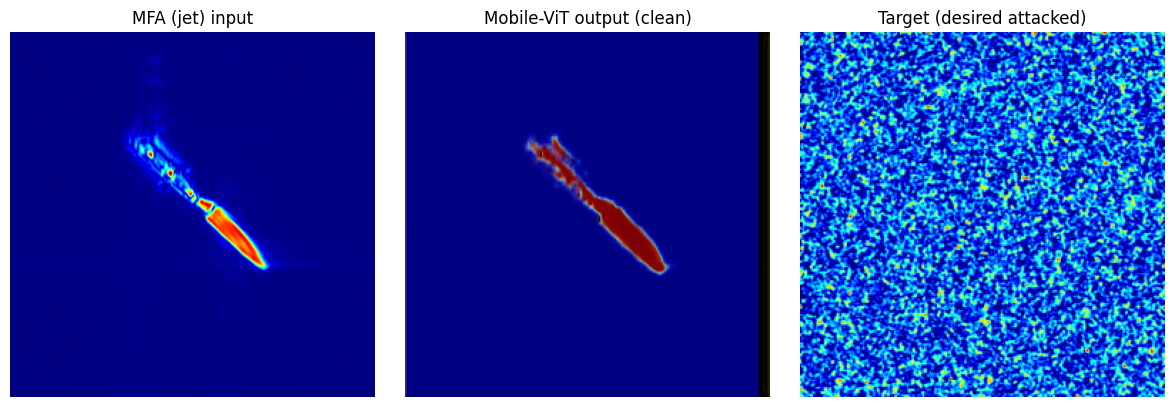

In [16]:
# ============================================================
# 5. Build attack target from desired_attacked_complex (401x401)
# ============================================================
mat_des = sio.loadmat("/content/drive/MyDrive/Colab Notebooks/Mobile_VIT_UTdallas/desired_attacked_complex.mat")
des_np = mat_des["sar_camouflaged"]   # (401,401) complex; adjust key if needed
print("desired_attacked_complex shape:", des_np.shape, des_np.dtype)

des_torch = torch.from_numpy(des_np).to(torch.complex64).to(device)

# magnitude + RMS norm
des_mag = torch.abs(des_torch)
rms_des = torch.sqrt(torch.mean(des_mag**2) + 1e-12)
des_mag_norm = des_mag / rms_des          # (401,401)

# min-max to [0,1]
x_des = des_mag_norm
x_des = x_des - x_des.min()
x_des = x_des / (x_des.max() + 1e-8)

# jet + resize to (256,256)
des_rgb = jet_torch(x_des)                   # (3,H,W)
des_rgb = des_rgb.unsqueeze(0)               # (1,3,H,W)
target_tensor = F.interpolate(
    des_rgb, size=(256,256),
    mode='bilinear', align_corners=False
).detach()                                   # (1,3,256,256)
print("target_tensor shape:", target_tensor.shape)


# ============================================================
# 6. Sanity check: clean victim output vs target
# ============================================================
with torch.no_grad():
    sr_clean, rgb_in_clean, mfa_mag_clean = victim_forward(raw_cube, params, model)

sr_img = sr_clean[0].detach().cpu().permute(1,2,0).numpy()
sr_img = np.clip(sr_img, 0.0, 1.0)

clean_rgb_vis = rgb_in_clean[0].detach().cpu().permute(1,2,0).numpy()
clean_rgb_vis = np.clip(clean_rgb_vis, 0.0, 1.0)

target_img = target_tensor[0].detach().cpu().permute(1,2,0).numpy()
target_img = np.clip(target_img, 0.0, 1.0)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(clean_rgb_vis); plt.title("MFA (jet) input"); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(sr_img);        plt.title("Mobile-ViT output (clean)"); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(target_img);    plt.title("Target (desired attacked)"); plt.axis('off')
plt.tight_layout(); plt.show()

D.mat was generated in MATLAB from iqData_noAtk / iqData_Atk and rawSAR. Here in Python, D (shape Nsamp x Np) is used as the fixed base attack waveform that will be combined with learnable gains A over the rawSAR measurements before running the differentiable MFA + Mobile-ViT pipeline.

In [17]:
import scipy.io as sio
import torch.nn.functional as F

# ============================================================
# 6. Load D from MATLAB and reshape to match raw_cube
# ============================================================
mat_D = sio.loadmat("/content/drive/MyDrive/Colab Notebooks/Mobile_VIT_UTdallas/D.mat")
D_np  = mat_D["D"]              # shape: (Nsamp, Np), complex from MATLAB

# Convert to torch complex and move to device
D = torch.from_numpy(D_np).to(torch.complex64).to(device)  # (Nsamp, Np)

Nsamp_D, Np_D = D.shape
Nsamp, M, N   = raw_cube.shape      # raw_cube: (Nsamp, M, N)

assert Nsamp_D == Nsamp, f"Nsamp mismatch: D={Nsamp_D}, raw_cube={Nsamp}"
assert Np_D    == M * N, f"Np mismatch: D={Np_D}, M*N={M*N}"

# Reshape to cube so each aperture location (m,n) has its own attack waveform over fast-time
D_cube = D.view(Nsamp, M, N)        # (Nsamp, M, N)

print("D_cube shape:", D_cube.shape)   # (Nsamp, M, N)

D_cube shape: torch.Size([256, 200, 200])


In [29]:
# ============================================================
# 7. Attack: optimize complex gain A over D_cube
#     Δ(t,m,n) = D_cube(t,m,n) * A(m,n)
# ============================================================

import math
import torch.nn.functional as F

Amax          = 2.0        # physical bound on |A(m,n)|
lambda_L2     = 1e-5       # L2 regularization on A
num_iters     = 1000
lr_high       = 1e-1
lr_low        = 1e-2
lr_switch_iter = 200       # iteration to drop LR

Nsamp, M, N = raw_cube.shape  # raw_cube: (Nsamp, M, N)

# ----- Latent variables Z; A is obtained via tanh mapping -----
Z_re = torch.nn.Parameter(1e-3 * torch.randn(M, N, device=device))
Z_im = torch.nn.Parameter(1e-3 * torch.randn(M, N, device=device))
optimizer = torch.optim.Adam([Z_re, Z_im], lr=lr_high)


def get_A_from_Z(Z_re, Z_im, Amax=2.0):
    """
    Smooth parameterization:

        A_re = (Amax / sqrt(2)) * tanh(Z_re)
        A_im = (Amax / sqrt(2)) * tanh(Z_im)

    so each component lies in [-Amax/sqrt(2), Amax/sqrt(2)],
    guaranteeing |A(m,n)| <= Amax without hard projection.
    """
    scale = Amax / math.sqrt(2.0)
    A_re = scale * torch.tanh(Z_re)
    A_im = scale * torch.tanh(Z_im)
    return A_re, A_im

optimizer = torch.optim.Adam([Z_re, Z_im], lr=lr_high)

print(f"\n[Attack] Starting DIA optimization over A, M={M}, N={N}, Np={M*N}\n")

for it in range(1, num_iters + 1):
    # Simple LR schedule: high LR, then lower after lr_switch_iter
    if it == lr_switch_iter + 1:
        for g in optimizer.param_groups:
            g["lr"] = lr_low
        print(f"[LR SCHEDULE] Switched Adam LR from {lr_high} to {lr_low}\n")

    optimizer.zero_grad()

    # Get bounded A from latent Z
    A_re_cur, A_im_cur = get_A_from_Z(Z_re, Z_im, Amax=Amax)  # (M, N) each
    A = torch.complex(A_re_cur, A_im_cur)                     # (M, N)

    # Structured perturbation: Δ(t,m,n) = D(t,m,n) * A(m,n)
    delta = D_cube * A.unsqueeze(0)   # (Nsamp, M, N), broadcast over fast-time

    # Attacked raw data
    raw_adv = raw_cube + delta        # (Nsamp, M, N)

    # Victim pipeline: rawSAR → range FFT/MFA → jet RGB → HFFH_ViT
    sr_adv, _, _ = victim_forward(raw_adv, params, model)  # (1,3,256,256)

    # Image-space loss (Mobile-ViT SR output vs target image in RGB)
    loss_img = F.mse_loss(sr_adv, target_tensor)

    # Regularization on *A* (not Z) to keep gains small
    loss_reg = lambda_L2 * (A_re_cur.pow(2).mean() + A_im_cur.pow(2).mean())

    loss = loss_img + loss_reg
    loss.backward()
    optimizer.step()

    if it % 10 == 0 or it == 1 or it == num_iters:
        with torch.no_grad():
            mse_now = F.mse_loss(sr_adv, target_tensor).item()
            meanA   = torch.mean(torch.abs(A)).item()
            maxA    = torch.max(torch.abs(A)).item()
        print(
            f"Iter {it:03d}/{num_iters:03d} | "
            f"Loss={loss.item():.4e} | ImgMSE={mse_now:.4e} | "
            f"mean|A|={meanA:.3e}, max|A|={maxA:.3e}"
        )

print("Attack optimization finished (reparameterized A).")

# Keep these handy if you want to use them later:a
A_final   = A.detach().cpu()         # (M, N) complex gain map
raw_adv_f = raw_adv.detach().cpu()   # attacked rawSAR
sr_adv_f  = sr_adv.detach().cpu()    # attacked Mobile-ViT output


[Attack] Starting DIA optimization over A, M=200, N=200, Np=40000

Iter 001/1000 | Loss=1.6167e-01 | ImgMSE=1.6167e-01 | mean|A|=1.771e-03, max|A|=6.161e-03
Iter 010/1000 | Loss=1.5723e-01 | ImgMSE=1.5722e-01 | mean|A|=6.900e-01, max|A|=1.301e+00
Iter 020/1000 | Loss=1.5699e-01 | ImgMSE=1.5698e-01 | mean|A|=8.751e-01, max|A|=1.657e+00
Iter 030/1000 | Loss=1.5682e-01 | ImgMSE=1.5681e-01 | mean|A|=9.518e-01, max|A|=1.776e+00
Iter 040/1000 | Loss=1.5666e-01 | ImgMSE=1.5665e-01 | mean|A|=9.998e-01, max|A|=1.805e+00
Iter 050/1000 | Loss=1.5651e-01 | ImgMSE=1.5650e-01 | mean|A|=1.039e+00, max|A|=1.819e+00
Iter 060/1000 | Loss=1.5634e-01 | ImgMSE=1.5633e-01 | mean|A|=1.074e+00, max|A|=1.832e+00
Iter 070/1000 | Loss=1.5613e-01 | ImgMSE=1.5611e-01 | mean|A|=1.112e+00, max|A|=1.860e+00
Iter 080/1000 | Loss=1.5592e-01 | ImgMSE=1.5590e-01 | mean|A|=1.150e+00, max|A|=1.870e+00
Iter 090/1000 | Loss=1.5560e-01 | ImgMSE=1.5558e-01 | mean|A|=1.188e+00, max|A|=1.870e+00
Iter 100/1000 | Loss=1.5515e-01 

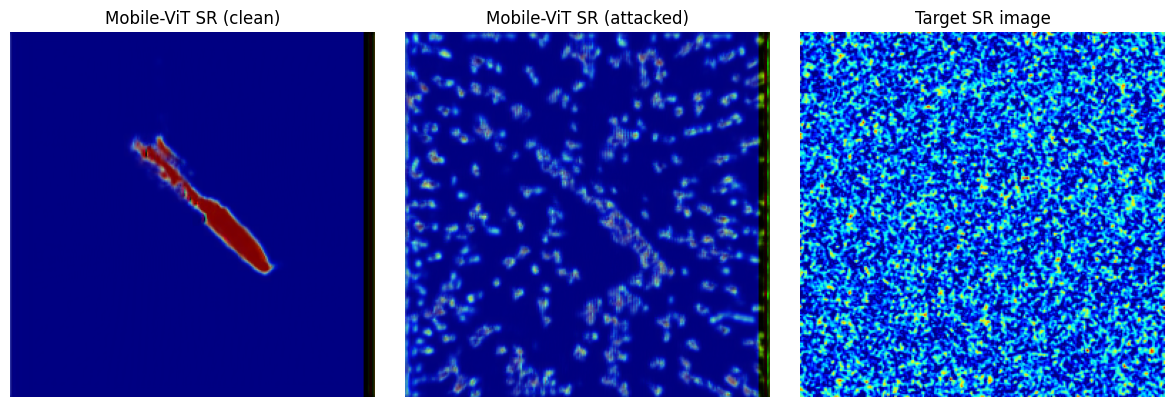

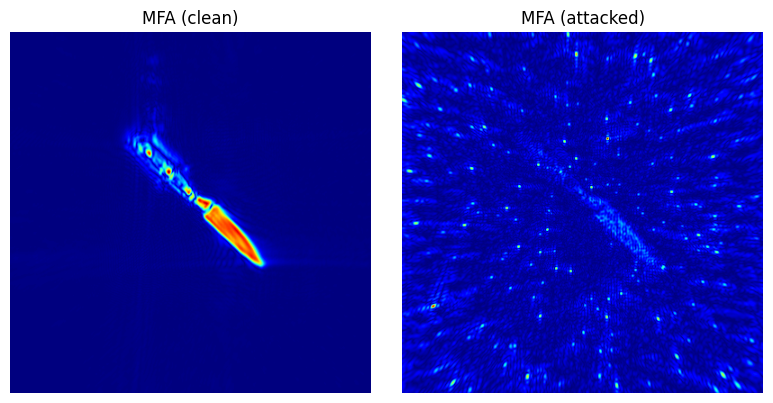

In [31]:
# ============================================================
# 8. Visualize final attacked vs clean vs target
# ============================================================
with torch.no_grad():
    # Clean pass
    sr_clean, rgb_clean, mfa_clean = victim_forward(raw_cube, params, model)
    # Attacked pass (using raw_adv from the attack loop)
    sr_adv,  rgb_adv,  mfa_adv   = victim_forward(raw_adv,  params, model)

    sr_clean_np = sr_clean[0].permute(1, 2, 0).cpu().numpy()
    sr_adv_np   = sr_adv[0].permute(1, 2, 0).cpu().numpy()
    target_np   = target_tensor[0].permute(1, 2, 0).cpu().numpy()

    # MFA magnitudes (assume mfa_* is (H,W) or (1,1,H,W))
    mfa_clean_np = mfa_clean
    mfa_adv_np   = mfa_adv

    if mfa_clean_np.ndim == 4:   # (B,1,H,W)
        mfa_clean_np = mfa_clean_np[0, 0].cpu().numpy()
        mfa_adv_np   = mfa_adv_np[0, 0].cpu().numpy()
    elif mfa_clean_np.ndim == 3: # (B,H,W)
        mfa_clean_np = mfa_clean_np[0].cpu().numpy()
        mfa_adv_np   = mfa_adv_np[0].cpu().numpy()
    else:                        # (H,W)
        mfa_clean_np = mfa_clean_np.cpu().numpy()
        mfa_adv_np   = mfa_adv_np.cpu().numpy()

# ---- Mobile-ViT SR outputs ----
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(sr_clean_np); plt.title("Mobile-ViT SR (clean)");   plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(sr_adv_np);   plt.title("Mobile-ViT SR (attacked)"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(target_np);   plt.title("Target SR image");         plt.axis("off")
plt.tight_layout()
plt.show()

# ---- MFA magnitude images (Mobile-ViT input domain) ----
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1);
plt.imshow(mfa_clean_np, cmap="jet");
plt.title("MFA (clean)");
plt.axis("off")

plt.subplot(1, 2, 2);
plt.imshow(mfa_adv_np, cmap="jet");
plt.title("MFA (attacked)");
plt.axis("off")

plt.tight_layout()
plt.show()


In [32]:
# ============================================================
# 9. Quantitative evaluation (Mobile-ViT output)
# ============================================================

att = sr_adv_np.astype(np.float32)
tgt = target_np.astype(np.float32)

mse_val  = np.mean((att - tgt) ** 2)
rmse_val = np.sqrt(mse_val)
mae_val  = np.mean(np.abs(att - tgt))

num = np.sum((att * tgt))
den = np.sqrt(np.sum(att**2) * np.sum(tgt**2)) + 1e-12
ncc_val = num / den

att_gray = np.mean(att, axis=2)
tgt_gray = np.mean(tgt, axis=2)
data_range = float(tgt_gray.max() - tgt_gray.min() + 1e-12)

ssim_val = ssim(att_gray, tgt_gray, data_range=data_range)
psnr_val = psnr(tgt_gray, att_gray, data_range=data_range)

print("\n--- Mobile-ViT SR-level attack metrics ---")
print(f"MSE   : {mse_val:.4e}")
print(f"RMSE  : {rmse_val:.4e}")
print(f"MAE   : {mae_val:.4e}")
print(f"NCC   : {ncc_val:.4f}")
print(f"SSIM  : {ssim_val:.4f}")
print(f"PSNR  : {psnr_val:.2f} dB")


--- Mobile-ViT SR-level attack metrics ---
MSE   : 1.2563e-01
RMSE  : 3.5445e-01
MAE   : 2.4248e-01
NCC   : 0.8297
SSIM  : 0.1106
PSNR  : 5.64 dB
